In [1]:
import os
import numpy as np
from scipy import stats
import pandas as pd
import warnings
import seaborn as sns
warnings.filterwarnings("ignore")

In [2]:
# Setting the working directory
import os
os.chdir(r'd:\Dowry-Demand-Prediction')

In [3]:
#Data collection and preprossesing 
data0 = pd.read_excel("Dataset//raw//data0.xlsx")
data1 = pd.read_excel("Dataset//raw//data1.xlsx")
data2 = pd.read_excel("Dataset//raw//data2.xlsx")
data3 = pd.read_excel("Dataset//raw//data3.xlsx")
data4 = pd.read_excel("Dataset//raw//data4.xlsx")
data5 = pd.read_excel("Dataset//raw//data5.xlsx")
data6 = pd.read_excel("Dataset//raw//data6.xlsx")
data7 = pd.read_excel("Dataset//raw//data7.xlsx")

In [4]:
#create a function to get all columns from each xlsx file.
def get_column_names(file_path):
    """Helper function to read column names from an Excel file."""
    try:
        df = pd.read_excel(file_path, nrows=0)  # Read only the header (column names)
        return df.columns.tolist()
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return None

In [5]:
#create a function to compare all columns from each xlsx file.
def check_xlsx_columns(directory):
    """Function to compare column names of all xlsx files in the given directory."""
    column_names = None
    first_file = None
    
    # Loop through all files in the directory
    for file in os.listdir(directory):
        if file.endswith(".xlsx"):
            file_path = os.path.join(directory, file)
            current_columns = get_column_names(file_path)
            
            if current_columns is None:
                return False  # If there was an error reading the file
            
            # If this is the first file, set the column names
            if column_names is None:
                column_names = current_columns
                first_file = file
            else:
                # Compare the current file's columns to the first file's columns
                if column_names != current_columns:
                    print(f"Column mismatch between {first_file} and {file}")
                    return False
    
    return True

In [6]:
directory = ".//Dataset//raw//"
result = check_xlsx_columns(directory)
if result:
    print("All files have identical column names.")
else:
    print("Files have different column names.")

All files have identical column names.


In [7]:
def concat_xlsx_files(directory, output_file):
    """Function to concatenate all xlsx files in a directory into one file."""
    dfs = []
    
    # Loop through all files in the directory
    for file in os.listdir(directory):
        if file.endswith(".xlsx"):
            file_path = os.path.join(directory, file)
            
            try:
                # Read the Excel file into a DataFrame
                df = pd.read_excel(file_path)
                dfs.append(df)
                print(f"Loaded {file} successfully.")
            except Exception as e:
                print(f"Error reading {file_path}: {e}")
                return False

    # Concatenate all DataFrames
    if dfs:
        final_df = pd.concat(dfs, ignore_index=True)
        
        # Save the concatenated DataFrame to an Excel file
        try:
            final_df.to_excel(output_file, index=False)
            print(f"Successfully saved concatenated file to {output_file}.")
            return True
        except Exception as e:
            print(f"Error saving to {output_file}: {e}")
            return False
    else:
        print("No data to concatenate.")
        return False

In [8]:
output_file = "Dataset//merged//Dowry-Data-Bangladesh.xlsx"
concat_xlsx_files(directory, output_file)

Loaded data0.xlsx successfully.
Loaded data1.xlsx successfully.
Loaded data2.xlsx successfully.
Loaded data3.xlsx successfully.
Loaded data4.xlsx successfully.
Loaded data5.xlsx successfully.
Loaded data6.xlsx successfully.
Loaded data7.xlsx successfully.
Successfully saved concatenated file to Dataset//merged//Dowry-Data-Bangladesh.xlsx.


True

In [9]:
data = pd.read_excel("Dataset//merged//Dowry-Data-Bangladesh.xlsx")

In [10]:
data.shape

(2433, 11)

In [11]:
data.sort_values(by="year",inplace=True,ignore_index=True)

## Cleaning

In [12]:
def transform_column(df, col_name, new_col_name):
    """
    This function transforms an existing column by:
    - Creating a new column with numeric values from the original column.
    - Replacing string values with 0 in the new column.
    - Converting numeric values to the string 'MONEY' in the original column.
    
    Parameters:
    - df: DataFrame
    - col_name: Name of the existing column
    - new_col_name: Name of the new column to be created
    
    Returns:
    - DataFrame with the transformed column and new column.
    """
    def extract_numeric(val):
        try:
            return float(val)
        except ValueError:
            return 0  # Replace non-numeric (string) values with 0

    # Create the new column with numeric values or 0 for strings
    df[new_col_name] = df[col_name].apply(extract_numeric)

    # Replace numeric values with 'MONEY' in the original column
    df[col_name] = df[col_name].apply(lambda x: 'Money' if str(x).replace('.', '', 1).isdigit() else x)

    return df


In [13]:
#creating new column having money values (NUMERIC) from dowry column
data = transform_column(data,col_name='dowry',new_col_name='dowry_money')

In [14]:
from preprocessing.dowry_normalizer import DowryDataNormalizer

normalizer = DowryDataNormalizer(data)
data = normalizer.normalize_all()

In [15]:
#deleting duplicates values if present.
data.drop_duplicates(inplace=True)

In [16]:
#checking for missing values.
data.isnull().sum()

year                       0
women's age                0
men's age                  0
family type                0
area                       0
girl's job                 0
boy's job                  0
marry condition            0
women married/unmarried    0
mohor                      0
dowry                      0
dowry_money                0
dtype: int64

In [17]:
#stats of data
data.describe()

,year,women's age,men's age,mohor,dowry_money
count,2433.000000,2433.000000,2433.000000,2.433000e+03,2433.000000
mean,2016.050966,20.439786,32.376079,4.362927e+05,264326.715988
std,1.684107,2.463836,4.830128,3.185015e+05,298976.306561
min,2013.000000,16.000000,25.000000,4.000000e+04,0.000000
25%,2015.000000,18.000000,29.000000,2.310000e+05,0.000000
50%,2017.000000,20.000000,32.000000,3.690000e+05,0.000000
75%,2017.000000,22.000000,36.000000,5.500000e+05,558500.000000
max,2018.000000,25.000000,42.000000,1.485000e+06,799700.000000


**women's age-**<br>
    **- Average age of marriage : 20**<br>
    **- Minimum age of marriage : 16**<br>
    **- Maximum age of marriage : 25**<br>

**men's age-**<br>
    **- Average age of marriage : 32**<br>
    **- Minimum age of marriage : 25**<br>
    **- Maximum age of marriage : 42**<br>

In [18]:
#function for checking outliers in columns
def detect_outliers_iqr(df, column):
    """
    Detects outliers in a specified column of a DataFrame using the IQR method.
    
    Parameters:
    df (pd.DataFrame): The DataFrame to check for outliers.
    column (str): The name of the column to check for outliers.
    
    Returns:
    pd.DataFrame: A DataFrame containing only the outliers.
    """
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Outliers are the values outside the IQR range
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
    return outliers


In [19]:
detect_outliers_iqr(data,"women's age")

Lower Bound: 12.0, Upper Bound: 28.0


,year,women's age,men's age,family type,area,girl's job,boy's job,marry condition,women married/unmarried,mohor,dowry,dowry_money


In [20]:
detect_outliers_iqr(data,"men's age")

Lower Bound: 18.5, Upper Bound: 46.5


,year,women's age,men's age,family type,area,girl's job,boy's job,marry condition,women married/unmarried,mohor,dowry,dowry_money


In [21]:
detect_outliers_iqr(data,"mohor").shape

Lower Bound: -247500.0, Upper Bound: 1028500.0


(231, 12)

In [22]:
def detect_outliers_zscore(df, column, threshold=3):
    """
    Detects outliers in a specified column of a DataFrame using the Z-score method.
    
    Parameters:
    df (pd.DataFrame): The DataFrame to check for outliers.
    column (str): The name of the column to check for outliers.
    threshold (float): The Z-score threshold to consider an outlier (default is 3).
    
    Returns:
    pd.DataFrame: A DataFrame containing only the outliers.
    """
    mean_col = df[column].mean()
    std_col = df[column].std()
    
    # Calculate the Z-scores
    df['Z_score'] = (df[column] - mean_col) / std_col
    
    # Outliers are values with Z-scores greater than the threshold (absolute value)
    outliers = df[np.abs(df['Z_score']) > threshold]
    
    return outliers


In [23]:
detect_outliers_zscore(data,"women's age")

,year,women's age,men's age,family type,area,girl's job,boy's job,marry condition,women married/unmarried,mohor,dowry,dowry_money,Z_score


In [24]:
detect_outliers_zscore(data,"men's age")

,year,women's age,men's age,family type,area,girl's job,boy's job,marry condition,women married/unmarried,mohor,dowry,dowry_money,Z_score


In [25]:
detect_outliers_zscore(data,"mohor").shape

(33, 13)

**The Interquartile Range (IQR) method is often better than the Z-score method for identifying outliers in skewed or non-normal data**
### **IQR method-**
**This method is more robust and less affected by extreme values, making it a better choice for identifying outliers in skewed distributions. It's also simple to calculate and the data spread is easy to interpret. However, it can only handle univariate data, and it can remove valid data points if the data is skewed or has heavy tails.** 
### **Z-score method-**
**This method is useful when data closely follow a normal distribution. It can be used to identify outliers, understand where an individual score fits into a distribution, and normalize scores for statistical decision-making. However, it can be sensitive to skewness and misidentify points as outliers. It can also have drawbacks when used for predictive modeling, such as losing the original meaning and scale of the data.**
**A Z-score is a standard score, which is the number of standard deviations by which a raw score is above or below the mean.**

In [26]:
def check_for_skew(data,column):
    skew_score = data[column].skew()
    if skew_score > 0:
        print("The distribution has a longer or fatter tail on the right side.(Positive skew)")
    else:
        print("The distribution has a longer or fatter tail on the left side.(Negative skew)")

In [27]:
check_for_skew(data,"mohor")

The distribution has a longer or fatter tail on the right side.(Positive skew)


**In the case of a positively skewed distribution, IQR tends to perform better.**

<Axes: xlabel='mohor'>

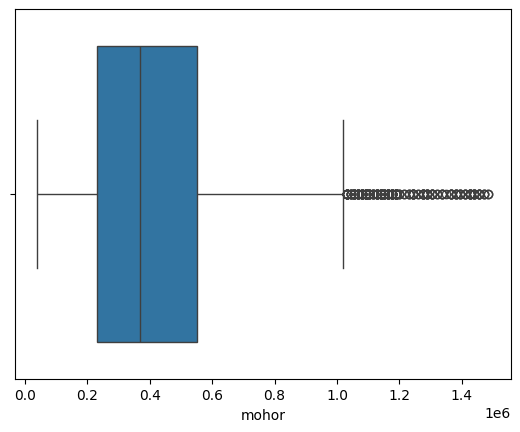

In [28]:
#box plot for checking outliers
sns.boxplot(data,x='mohor',)

In [29]:
def reduce_skewness(data,column):
    data[column], _ = stats.boxcox(data[column])

In [30]:
reduce_skewness(data,'mohor')

In [31]:
print("Total rows having outliers : ",detect_outliers_iqr(data,'mohor').shape)

Lower Bound: 28.422518574417577, Upper Bound: 54.63903302560681
Total rows having outliers :  (35, 13)


**Now only 35 rows (outliers) are remaining out of 2433 rows, so we can remove them.**

In [32]:
#removing 35 rows 
Q1 = data["mohor"].quantile(0.25)
Q3 = data["mohor"].quantile(0.75)
IQR = Q3 - Q1
            
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
data = data[(data["mohor"] >= lower_bound) & (data["mohor"] <= upper_bound)]

In [33]:
print("Total rows having outliers : ",detect_outliers_iqr(data,'mohor').shape)
print("Value of skewness : ",data["mohor"].skew())
check_for_skew(data,"mohor")

Lower Bound: 28.203681775090967, Upper Bound: 55.00376102448449
Total rows having outliers :  (0, 13)
Value of skewness :  0.12461171327726138
The distribution has a longer or fatter tail on the right side.(Positive skew)


<Axes: xlabel='mohor', ylabel='Density'>

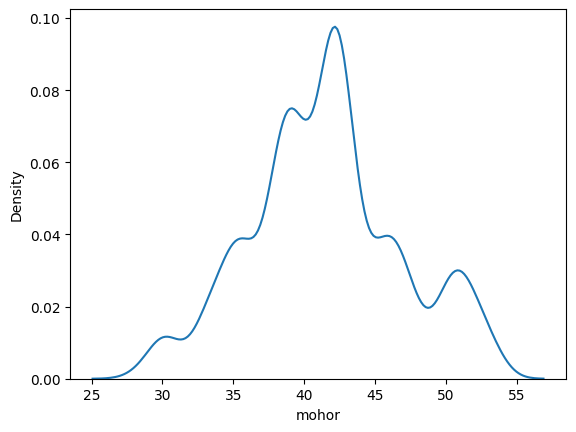

In [34]:
sns.kdeplot(data,x="mohor",)

**Now column is noramlly distributed.**

In [35]:
data.drop(columns='Z_score',inplace=True)

In [38]:
# Save the cleaned data to the specified directory
cleaned_output_file = "Dataset/cleaned/Dowry-Data-Bangladesh-cleaned.xlsx"
data.to_excel(cleaned_output_file, index=False)
print(f"Cleaned data saved to {cleaned_output_file}")

Cleaned data saved to Dataset/cleaned/Dowry-Data-Bangladesh-cleaned.xlsx
